<a href="https://colab.research.google.com/github/pronomi1210/cousera-test/blob/main/workshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# XOR gate
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

model = Sequential()

model.add(Dense(4, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.fit(X, y, epochs=1000, verbose=0)

predictions = model.predict(X)

print("Predictions for XOR logic gate:")
for i in range(len(X)):
    print(f"Input: {X[i]}, Predicted Output: {np.round(predictions[i][0])}, Actual Output: {y[i][0]}")


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predictions for XOR logic gate:
Input: [0 0], Predicted Output: 0.0, Actual Output: 0
Input: [0 1], Predicted Output: 0.0, Actual Output: 1
Input: [1 0], Predicted Output: 1.0, Actual Output: 1
Input: [1 1], Predicted Output: 0.0, Actual Output: 0


In [ ]:
#exp12
import numpy as np
import cv2
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.datasets import mnist
import matplotlib.pyplot as plt

# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Reshape and normalize the data
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32') / 255
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32') / 255

# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=3, validation_split=0.2)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Save the trained model
model.save('mnist_cnn_model.h5')

# Function to preprocess a custom input image
def preprocess_image(image_path):
    # Load the image in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    # Resize the image to 28x28 pixels (same as MNIST dataset)
    img = cv2.resize(img, (28, 28))
    # Invert the colors if the background is white
    img = 255 - img
    # Normalize the pixel values to be between 0 and 1
    img = img.astype('float32') / 255.0
    # Reshape to fit the model's input shape (1, 28, 28, 1)
    img = np.reshape(img, (1, 28, 28, 1))
    return img

# Predict on a custom input image
def predict_custom_image(image_path):
    # Load the trained model
    model = tf.keras.models.load_model('mnist_cnn_model.h5')
    # Preprocess the input image
    img = preprocess_image(image_path)
    # Make a prediction
    prediction = model.predict(img)
    # Print the predicted class
    print(f"Predicted digit: {np.argmax(prediction)}")

# Example usage
image_path = 'path/to/your/handwritten_digit.png'  # Replace with your image path
predict_custom_image(image_path)


Epoch 1/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 33ms/step - accuracy: 0.8965 - loss: 0.3264 - val_accuracy: 0.9769 - val_loss: 0.0737
Epoch 2/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 96s 42ms/step - accuracy: 0.9849 - loss: 0.0492 - val_accuracy: 0.9876 - val_loss: 0.0416
Epoch 3/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 70s 34ms/step - accuracy: 0.9900 - loss: 0.0303 - val_accuracy: 0.9875 - val_loss: 0.0447
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9869 - loss: 0.0432


Test Accuracy: 0.9896


NameError: name 'tf' is not defined

In [ ]:
import numpy as np
import cv2
import tensorflow as tf  # Import TensorFlow
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.datasets import mnist
import matplotlib.pyplot as plt

# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Reshape and normalize the data
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32') / 255
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32') / 255

# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, validation_split=0.2)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Save the trained model
model.save('mnist_cnn_model.h5')

# Function to preprocess a custom input image
def preprocess_image(image_path):
    # Load the image in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    # Resize the image to 28x28 pixels (same as MNIST dataset)
    img = cv2.resize(img, (28, 28))
    # Invert the colors if the background is white
    img = 255 - img
    # Normalize the pixel values to be between 0 and 1
    img = img.astype('float32') / 255.0
    # Reshape to fit the model's input shape (1, 28, 28, 1)
    img = np.reshape(img, (1, 28, 28, 1))
    return img

# Predict on a custom input image
def predict_custom_image(image_path):
    # Load the trained model
    model = tf.keras.models.load_model('mnist_cnn_model.h5')
    # Preprocess the input image
    img = preprocess_image(image_path)
    # Make a prediction
    prediction = model.predict(img)
    # Print the predicted class
    print(f"Predicted digit: {np.argmax(prediction)}")

# Example usage
image_path = 'path/to/your/handwritten_digit.png'  # Replace with your image path
predict_custom_image(image_path)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 76s 48ms/step - accuracy: 0.8940 - loss: 0.3414 - val_accuracy: 0.9839 - val_loss: 0.0545
Epoch 2/10
  92/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 32ms/step - accuracy: 0.9852 - loss: 0.0438

KeyboardInterrupt: 

In [ ]:
class BikeRental:
    def __init__(self, stock=0):
        """
        Initializes the bike rental shop with a given stock of bikes.
        """
        self.stock = stock
        self.revenue = 0

    def display_stock(self):
        """
        Displays the number of bikes currently available for rent.
        """
        print(f"Available bikes for rent: {self.stock}")

    def rent_bike_on_hourly_basis(self, num_of_bikes):
        """
        Rents bikes on an hourly basis.
        """
        if num_of_bikes <= 0:
            print("Number of bikes should be positive!")
            return None
        elif num_of_bikes > self.stock:
            print(f"Sorry, we have only {self.stock} bikes available.")
            return None
        else:
            self.stock -= num_of_bikes
            print(f"You have rented {num_of_bikes} bike(s) on an hourly basis.")
            return {'basis': 'hourly', 'bikes': num_of_bikes}

    def rent_bike_on_daily_basis(self, num_of_bikes):
        """
        Rents bikes on a daily basis.
        """
        if num_of_bikes <= 0:
            print("Number of bikes should be positive!")
            return None
        elif num_of_bikes > self.stock:
            print(f"Sorry, we have only {self.stock} bikes available.")
            return None
        else:
            self.stock -= num_of_bikes
            print(f"You have rented {num_of_bikes} bike(s) on a daily basis.")
            return {'basis': 'daily', 'bikes': num_of_bikes}

    def return_bike(self, rental_info):
        """
        Returns the bike to the shop.
        """
        if rental_info is None:
            print("Invalid rental info!")
            return

        num_of_bikes = rental_info['bikes']
        basis = rental_info['basis']

        self.stock += num_of_bikes

        if basis == 'hourly':
            charge = num_of_bikes * 5  # $5 per hour per bike
        elif basis == 'daily':
            charge = num_of_bikes * 20  # $20 per day per bike
        else:
            print("Invalid rental basis!")
            return

        self.revenue += charge
        print(f"Thank you for returning {num_of_bikes} bike(s). Your charge is ${charge}.")
        print(f"Total revenue now: ${self.revenue}")


# Example Usage
if __name__ == "__main__":
    # Create an instance of the bike rental shop with 10 bikes
    shop = BikeRental(10)

    # Display available bikes
    shop.display_stock()

    # Rent 3 bikes on an hourly basis
    rental = shop.rent_bike_on_hourly_basis(3)

    # Display available bikes after renting
    shop.display_stock()

    # Return the rented bikes
    shop.return_bike(rental)

    # Display available bikes after returning
    shop.display_stock()


Available bikes for rent: 10
You have rented 3 bike(s) on an hourly basis.
Available bikes for rent: 7
Thank you for returning 3 bike(s). Your charge is $15.
Total revenue now: $15
Available bikes for rent: 10


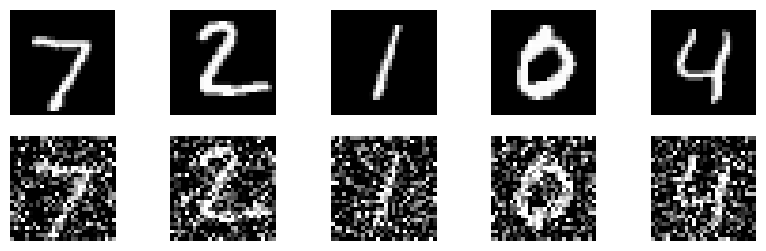

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 162s 288ms/step - loss: 0.2475 - val_loss: 0.1186
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 138s 281ms/step - loss: 0.1162 - val_loss: 0.1089
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 140s 276ms/step - loss: 0.1090 - val_loss: 0.1053
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 278ms/step - loss: 0.1059 - val_loss: 0.1042
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 139s 272ms/step - loss: 0.1041 - val_loss: 0.1015
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 127s 271ms/step - loss: 0.1022 - val_loss: 0.1005
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 270ms/step - loss: 0.1010 - val_loss: 0.0997
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 126s 269ms/step - loss: 0.1003 - val_loss: 0.0989
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 124s 265ms/step - loss: 0.0996 - val_loss: 0.0981
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 268ms/step - loss: 0.0991 - val_loss: 0.0977
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step


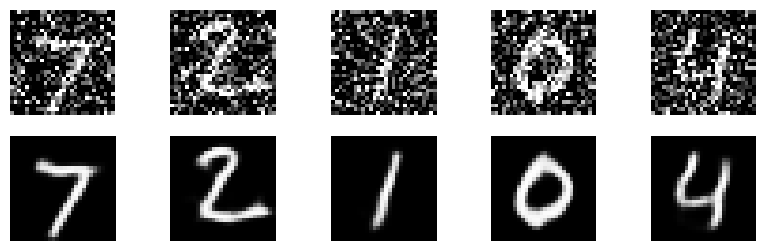

In [ ]:
#denoise an encoder
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from keras.models import Sequential, Model
from keras.layers import Dense, Input, Flatten, Reshape
from keras.layers import Conv2D, MaxPooling2D, UpSampling2D

# Load and preprocess the MNIST dataset
(X_train, _), (X_test, _) = mnist.load_data()

# Normalize the pixel values
X_train = X_train.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.

# Reshape the data to add a single color channel
X_train = np.reshape(X_train, (len(X_train), 28, 28, 1))
X_test = np.reshape(X_test, (len(X_test), 28, 28, 1))

# Add random noise to the images
noise_factor = 0.5
X_train_noisy = X_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_train.shape)
X_test_noisy = X_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_test.shape)

# Clip the values to be between 0 and 1
X_train_noisy = np.clip(X_train_noisy, 0., 1.)
X_test_noisy = np.clip(X_test_noisy, 0., 1.)

# Display original, noisy, and clean images
n = 5
plt.figure(figsize=(10, 3))
for i in range(n):
    # Display original images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.axis('off')

    # Display noisy images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(X_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.axis('off')

plt.show()

# Build the autoencoder model
input_img = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

# Decoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Combine the encoder and decoder into an autoencoder model
autoencoder = Model(input_img, decoded)

# Compile the model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train the model
autoencoder.fit(X_train_noisy, X_train,
                epochs=10,
                batch_size=128,
                shuffle=True,
                validation_data=(X_test_noisy, X_test))

# Predict on the noisy test data
denoised_images = autoencoder.predict(X_test_noisy)

# Display the noisy and denoised images
plt.figure(figsize=(10, 3))
for i in range(n):
    # Display noisy images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.axis('off')

    # Display denoised images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
    plt.axis('off')

plt.show()


Accuracy: 0.89

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90       160
           1       0.88      0.90      0.89       140

    accuracy                           0.89       300
   macro avg       0.89      0.89      0.89       300
weighted avg       0.89      0.89      0.89       300


Confusion Matrix:
[[142  18]
 [ 14 126]]


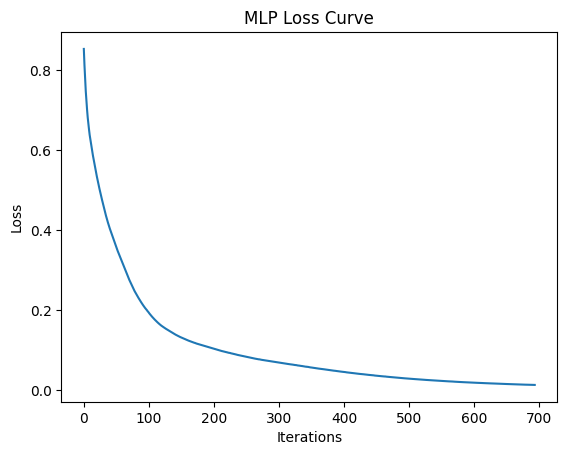

In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Step 1: Generate a random dataset
X, y = make_classification(n_samples=1000,
                           n_features=20,
                           n_informative=15,
                           n_redundant=5,
                           n_classes=2,
                           random_state=42)

# Step 2: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Initialize the MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(10, 10),
                    max_iter=1000,
                    activation='relu',
                    solver='adam',
                    random_state=42)

# Step 4: Train the model
mlp.fit(X_train, y_train)

# Step 5: Predict on the test set
y_pred = mlp.predict(X_test)

# Step 6: Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Step 7: (Optional) Plot the loss curve
plt.plot(mlp.loss_curve_)
plt.title('MLP Loss Curve')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.show()


TensorFlow version: 2.17.0
Tensor 1:
 tf.Tensor(
[[1 2]
 [3 4]], shape=(2, 2), dtype=int32)
Tensor 2:
 tf.Tensor(
[[5 6]
 [7 8]], shape=(2, 2), dtype=int32)
Sum of tensors:
 tf.Tensor(
[[ 6  8]
 [10 12]], shape=(2, 2), dtype=int32)
Element-wise multiplication of tensors:
 tf.Tensor(
[[ 5 12]
 [21 32]], shape=(2, 2), dtype=int32)
Dot product of tensors:
 tf.Tensor(
[[19 22]
 [43 50]], shape=(2, 2), dtype=int32)
Variable:
 <tf.Variable 'Variable:0' shape=(2, 2) dtype=float32, numpy=
array([[1., 2.],
       [3., 4.]], dtype=float32)>
Updated Variable:
 <tf.Variable 'Variable:0' shape=(2, 2) dtype=float32, numpy=
array([[2., 3.],
       [4., 5.]], dtype=float32)>
Model Summary:


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.5715 - loss: 0.6134 - val_accuracy: 0.7714 - val_loss: 0.6004
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7670 - loss: 0.5888 - val_accuracy: 0.8071 - val_loss: 0.5709
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8273 - loss: 0.5512 - val_accuracy: 0.8429 - val_loss: 0.5443
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8314 - loss: 0.5349 - val_accuracy: 0.8500 - val_loss: 0.5205
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8594 - loss: 0.5174 - val_accuracy: 0.8714 - val_loss: 0.4977
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8721 - loss: 0.4888 - val_accuracy: 0.8786 - val_loss: 0.4772
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8624 - loss: 0.4739 - val_accuracy: 0.8786 - val_loss: 0.4579
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8629 - loss: 0.4523 - val_accuracy: 0.8786 -

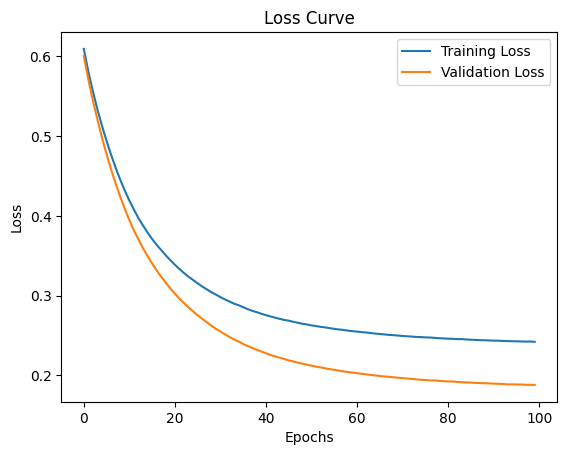

In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

### 1. Creating and Manipulating Tensors

tensor1 = tf.constant([[1, 2], [3, 4]])
tensor2 = tf.constant([[5, 6], [7, 8]])

sum_tensors = tf.add(tensor1, tensor2)
mul_tensors = tf.multiply(tensor1, tensor2)
dot_product = tf.matmul(tensor1, tensor2)

print("Tensor 1:\n", tensor1)
print("Tensor 2:\n", tensor2)
print("Sum of tensors:\n", sum_tensors)
print("Element-wise multiplication of tensors:\n", mul_tensors)
print("Dot product of tensors:\n", dot_product)

### 2. Using Variables

variable = tf.Variable([[1.0, 2.0], [3.0, 4.0]])
print("Variable:\n", variable)

variable.assign_add([[1.0, 1.0], [1.0, 1.0]])
print("Updated Variable:\n", variable)

### 3. Building a Simple Neural Network

X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = Sequential([
    Dense(10, activation='relu', input_shape=(2,)),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Print model summary
print("Model Summary:")
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

# Make predictions
predictions = model.predict(X_test)
predicted_classes = (predictions > 0.5).astype(int)

# Print the first few predictions
print("First few predictions:", predicted_classes[:5].flatten())

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


TensorFlow version: 2.17.0
Model Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7633 - loss: 0.5554 - val_accuracy: 0.8571 - val_loss: 0.5081
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8162 - loss: 0.5237 - val_accuracy: 0.8643 - val_loss: 0.4854
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8142 - loss: 0.4995 - val_accuracy: 0.8643 - val_loss: 0.4648
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7999 - loss: 0.4960 - val_accuracy: 0.8643 - val_loss: 0.4460
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8166 - loss: 0.4684 - val_accuracy: 0.8643 - val_loss: 0.4290
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8179 - loss: 0.4550 - val_accuracy: 0.8643 - val_loss: 0.4133
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7906 - loss: 0.4571 - val_accuracy: 0.8643 - val_loss: 0.3991
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8078 - loss: 0.4342 - val_accuracy: 0.8643 - 

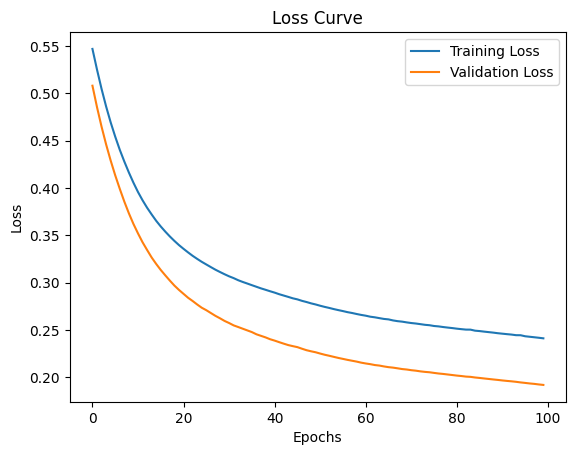

In [ ]:
# Import necessary libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Check TensorFlow version
print("TensorFlow version:", tf.__version__)

### 1. Generate a Random Dataset

X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### 2. Build a Simple Neural Network Model

model = Sequential([
    Dense(10, activation='relu', input_shape=(2,)),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Print model summary
print("Model Summary:")
model.summary()

### 3. Train the Model

history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1)

### 4. Evaluate the Model

loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

### 5. Make Predictions

# Make predictions on the test set
predictions = model.predict(X_test)
predicted_classes = (predictions > 0.5).astype(int)

# Print the first few predictions
print("First few predictions:", predicted_classes[:5].flatten())

### 6. Visualize the Learning Curve

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


Model Accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Predictions:
 [[0.02175034]
 [0.9866533 ]
 [0.98275036]
 [0.01371503]]
Actual XOR outputs:
 [[0]
 [1]
 [1]
 [0]]


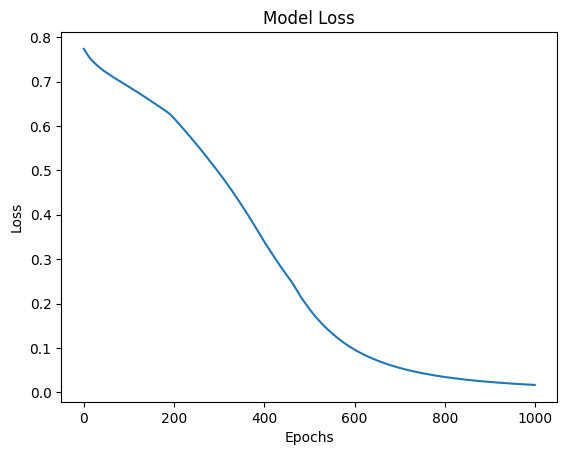

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

# XOR input and output data
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

# Define the model
model = Sequential([
    Dense(8, input_dim=2, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X, y, epochs=1000, verbose=0)

# Evaluate the model
loss, accuracy = model.evaluate(X, y, verbose=0)
print(f"Model Accuracy: {accuracy:.4f}")

# Make predictions
predictions = model.predict(X)
print("Predictions:\n", predictions)

# Print the actual XOR outputs
print("Actual XOR outputs:\n", y)

# Visualize the loss curve
plt.plot(history.history['loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


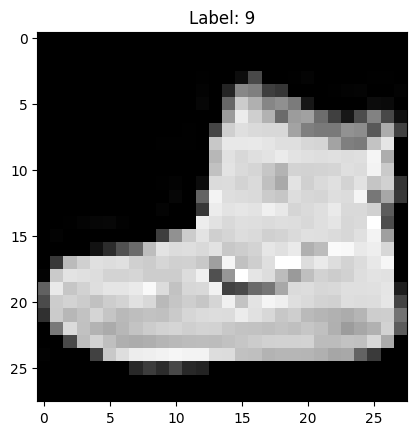

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - accuracy: 0.7700 - loss: 0.6662 - val_accuracy: 0.8478 - val_loss: 0.4311
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - accuracy: 0.8589 - loss: 0.3863 - val_accuracy: 0.8610 - val_loss: 0.3713
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.8727 - loss: 0.3453 - val_accuracy: 0.8740 - val_loss: 0.3574
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8851 - loss: 0.3188 - val_accuracy: 0.8838 - val_loss: 0.3260
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8896 - loss: 0.2984 - val_accuracy: 0.8816 - val_loss: 0.3322
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8961 - loss: 0.2844 - val_accuracy: 0.8731 - val_loss: 0.3571
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8963 - loss: 0.2724 - val_accuracy: 0.8677 - val_loss: 0.3685
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9030 - loss: 0.2

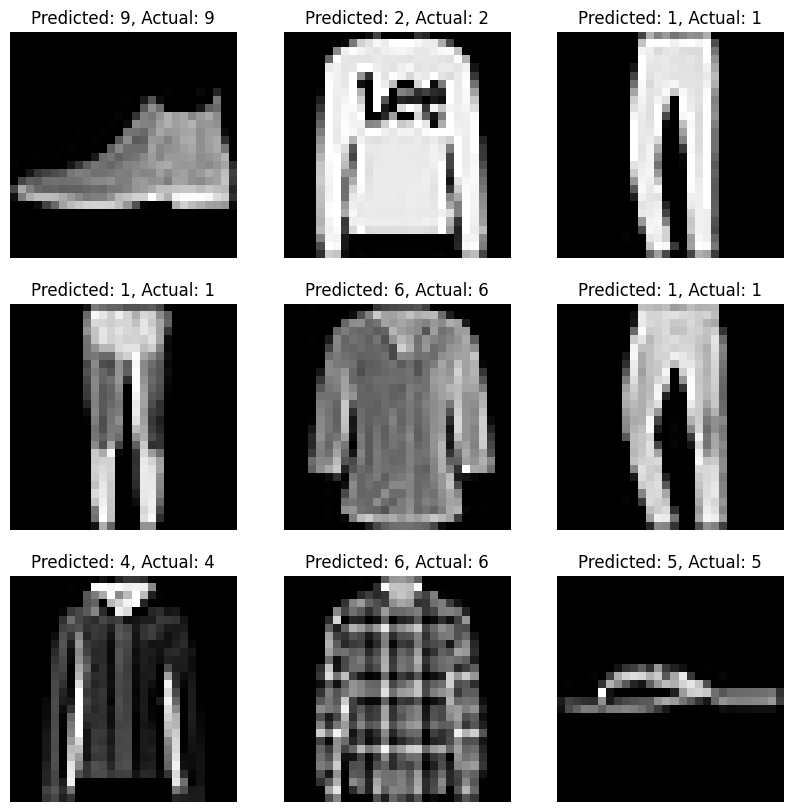

In [ ]:
# lab 9
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

# Load the Fashion MNIST dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the images to a range of 0 to 1
X_train, X_test = X_train / 255.0, X_test / 255.0

# Display the first image in the training set
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

# Build the neural network model
model = Sequential([
    Flatten(input_shape=(28, 28)),            # Flatten the input
    Dense(128, activation='relu'),            # Hidden layer with 128 neurons
    Dense(64, activation='relu'),             # Second hidden layer with 64 neurons
    Dense(10, activation='softmax')           # Output layer with 10 neurons (one for each class)
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, validation_split=0.2)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Make predictions
predictions = model.predict(X_test)

# Display a few predictions
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"Predicted: {tf.argmax(predictions[i]).numpy()}, Actual: {y_test[i]}")
    plt.axis('off')
plt.show()


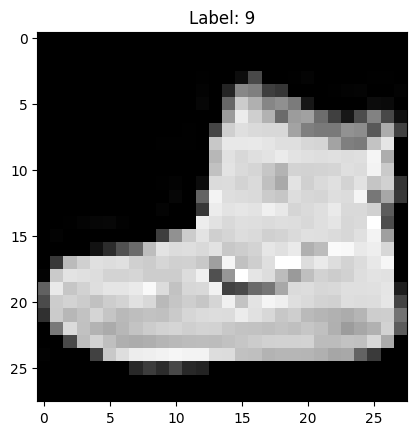

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7658 - loss: 0.6721 - val_accuracy: 0.8482 - val_loss: 0.4171
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8576 - loss: 0.3927 - val_accuracy: 0.8580 - val_loss: 0.3865
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8716 - loss: 0.3481 - val_accuracy: 0.8705 - val_loss: 0.3745
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8825 - loss: 0.3158 - val_accuracy: 0.8777 - val_loss: 0.3396
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8932 - loss: 0.2901 - val_accuracy: 0.8714 - val_loss: 0.3539
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8945 - loss: 0.2817 - val_accuracy: 0.8823 - val_loss: 0.3225
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9004 - loss: 0.2632 - val_accuracy: 0.8737 - val_loss: 0.3422
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9021 - loss: 0.2591 -

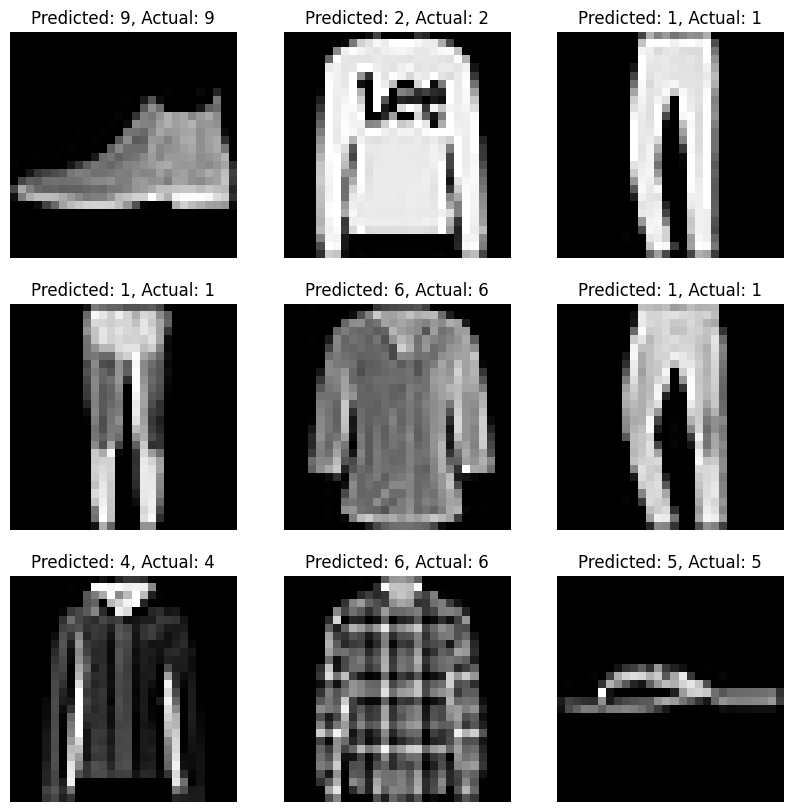

In [ ]:
#lab10
# Import necessary libraries
from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

# Load the Fashion MNIST dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the images to a range of 0 to 1
X_train, X_test = X_train / 255.0, X_test / 255.0

# Display the first image in the training set
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

# Build the neural network model
model = Sequential([
    Flatten(input_shape=(28, 28)),            # Flatten the input
    Dense(128, activation='relu'),            # Hidden layer with 128 neurons
    Dense(64, activation='relu'),             # Second hidden layer with 64 neurons
    Dense(10, activation='softmax')           # Output layer with 10 neurons (one for each class)
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, validation_split=0.2)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Make predictions
predictions = model.predict(X_test)

# Display a few predictions
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"Predicted: {predictions[i].argmax()}, Actual: {y_test[i]}")
    plt.axis('off')
plt.show()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


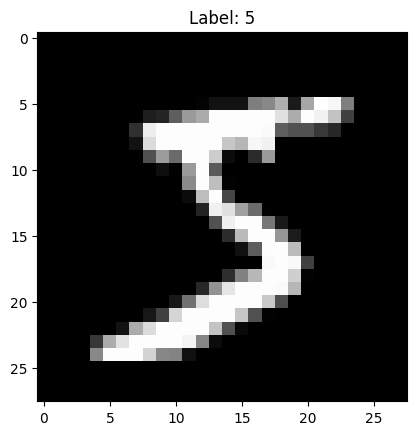

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8655 - loss: 0.4617 - val_accuracy: 0.9553 - val_loss: 0.1477
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9643 - loss: 0.1159 - val_accuracy: 0.9677 - val_loss: 0.1080
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9765 - loss: 0.0761 - val_accuracy: 0.9695 - val_loss: 0.0974
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9820 - loss: 0.0565 - val_accuracy: 0.9697 - val_loss: 0.1063
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9864 - loss: 0.0437 - val_accuracy: 0.9707 - val_loss: 0.1000
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9898 - loss: 0.0337 - val_accuracy: 0.9747 - val_loss: 0.0914
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9922 - loss: 0.0248 - val_accuracy: 0.9703 - val_loss: 0.1169
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9910 - loss: 0.0250 

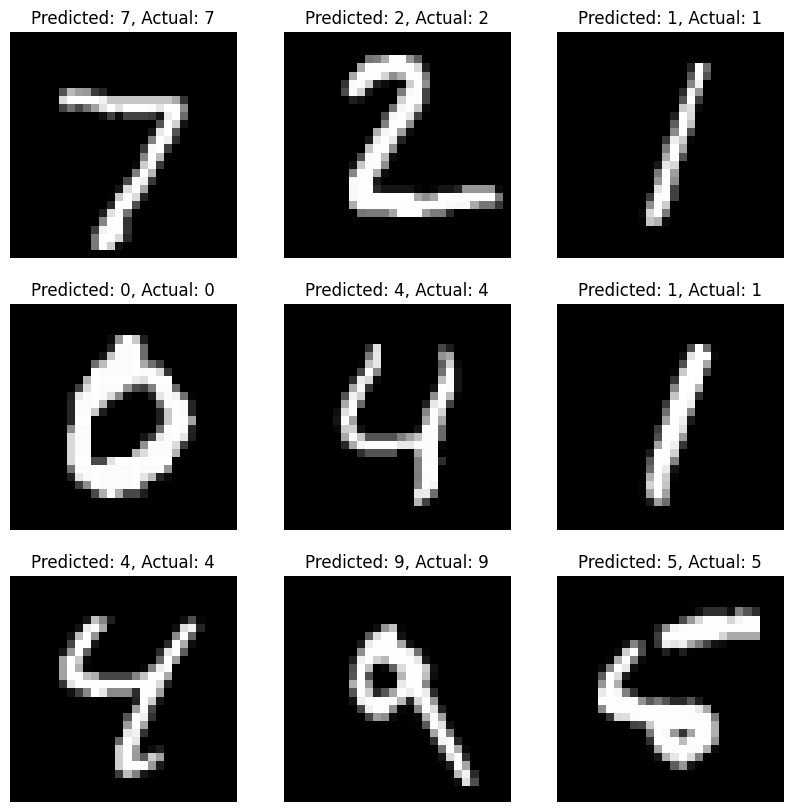

In [ ]:
#exp11
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize the images to a range of 0 to 1
X_train, X_test = X_train / 255.0, X_test / 255.0

# Display the first image in the training set
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

# Build the neural network model
model = Sequential([
    Flatten(input_shape=(28, 28)),            # Flatten the input
    Dense(128, activation='relu'),            # Hidden layer with 128 neurons
    Dense(64, activation='relu'),             # Second hidden layer with 64 neurons
    Dense(10, activation='softmax')           # Output layer with 10 neurons (one for each class)
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, validation_split=0.2)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Make predictions
predictions = model.predict(X_test)

# Display a few predictions
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"Predicted: {predictions[i].argmax()}, Actual: {y_test[i]}")
    plt.axis('off')
plt.show()


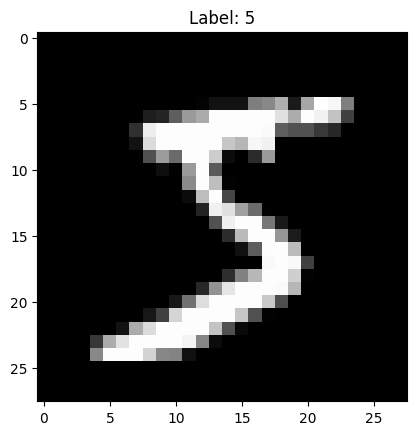

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8604 - loss: 0.4726 - val_accuracy: 0.9592 - val_loss: 0.1390
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9668 - loss: 0.1103 - val_accuracy: 0.9656 - val_loss: 0.1169
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9780 - loss: 0.0731 - val_accuracy: 0.9700 - val_loss: 0.0998
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9820 - loss: 0.0549 - val_accuracy: 0.9741 - val_loss: 0.0921
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9863 - loss: 0.0400 - val_accuracy: 0.9734 - val_loss: 0.0919
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9905 - loss: 0.0300 - val_accuracy: 0.9729 - val_loss: 0.1017
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9921 - loss: 0.0235 - val_accuracy: 0.9754 - val_loss: 0.1022
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9942 - loss: 0.0201 -

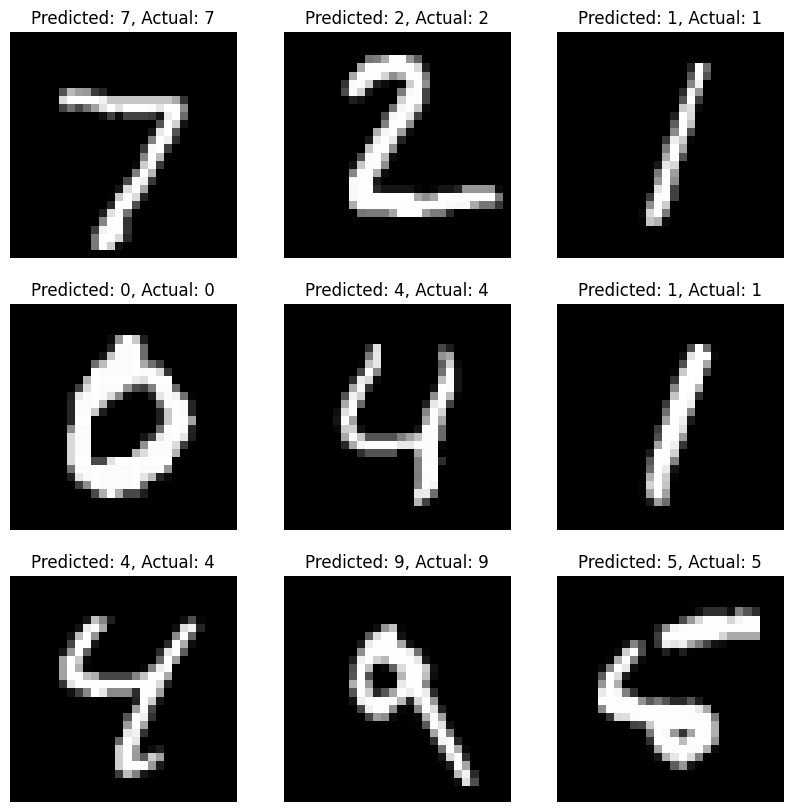

In [ ]:
#exp 12
# Import necessary libraries
from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.datasets import mnist
import matplotlib.pyplot as plt

# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize the images to a range of 0 to 1
X_train, X_test = X_train / 255.0, X_test / 255.0

# Display the first image in the training set
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

# Build the neural network model
model = Sequential([
    Flatten(input_shape=(28, 28)),            # Flatten the input
    Dense(128, activation='relu'),            # Hidden layer with 128 neurons
    Dense(64, activation='relu'),             # Second hidden layer with 64 neurons
    Dense(10, activation='softmax')           # Output layer with 10 neurons (one for each digit)
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, validation_split=0.2)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Make predictions
predictions = model.predict(X_test)

# Display a few predictions
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"Predicted: {predictions[i].argmax()}, Actual: {y_test[i]}")
    plt.axis('off')
plt.show()


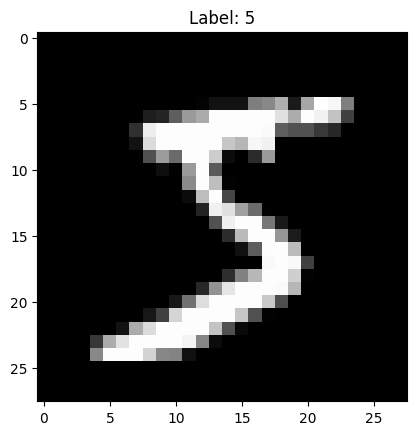

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 32ms/step - accuracy: 0.8945 - loss: 0.3411 - val_accuracy: 0.9834 - val_loss: 0.0613
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 33ms/step - accuracy: 0.9852 - loss: 0.0483 - val_accuracy: 0.9855 - val_loss: 0.0472
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 31ms/step - accuracy: 0.9905 - loss: 0.0306 - val_accuracy: 0.9874 - val_loss: 0.0472
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 32ms/step - accuracy: 0.9918 - loss: 0.0242 - val_accuracy: 0.9889 - val_loss: 0.0420
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 31ms/step - accuracy: 0.9953 - loss: 0.0141 - val_accuracy: 0.9887 - val_loss: 0.0439
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 84s 33ms/step - accuracy: 0.9966 - loss: 0.0107 - val_accuracy: 0.9912 - val_loss: 0.0369
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.9974 - loss: 0.0082 - val_accuracy: 0.9881 - val_loss: 0.0472
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 32ms/step - accuracy: 0.9978 -

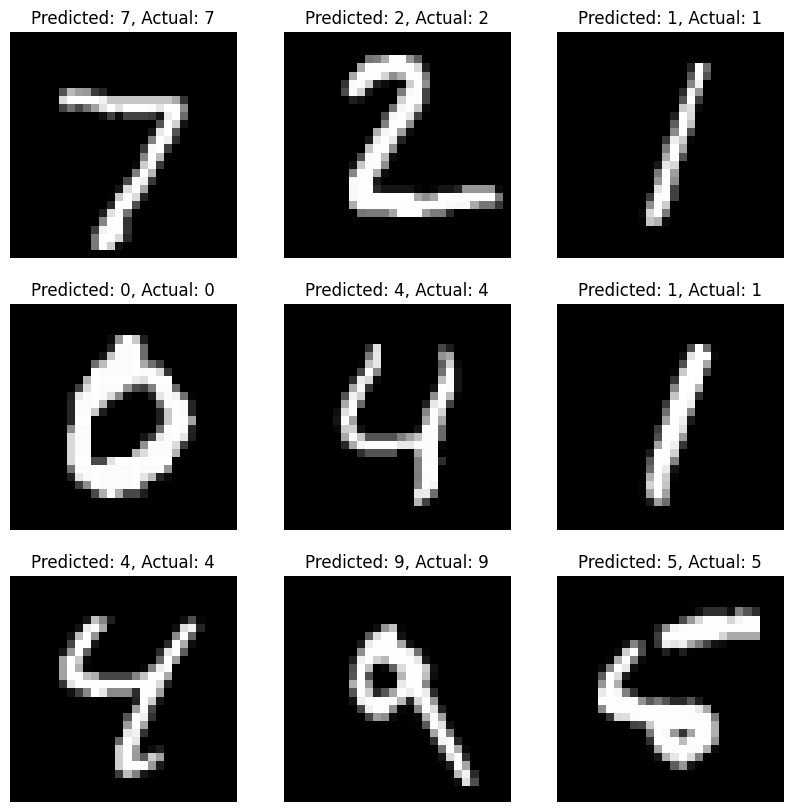

In [ ]:
#exp13
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Reshape the data to include a single color channel (grayscale)
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

# Normalize the pixel values
X_train, X_test = X_train / 255.0, X_test / 255.0

# Display the first image in the training set
plt.imshow(X_train[0].reshape(28, 28), cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),  # First convolutional layer
    MaxPooling2D(pool_size=(2, 2)),                                  # Max pooling layer
    Conv2D(64, (3, 3), activation='relu'),                           # Second convolutional layer
    MaxPooling2D(pool_size=(2, 2)),                                  # Max pooling layer
    Flatten(),                                                       # Flatten the tensor output
    Dense(128, activation='relu'),                                   # Fully connected layer
    Dense(10, activation='softmax')                                  # Output layer
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, validation_split=0.2)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Make predictions
predictions = model.predict(X_test)

# Display a few predictions
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {predictions[i].argmax()}, Actual: {y_test[i]}")
    plt.axis('off')
plt.show()


TensorFlow version: 2.17.0
Model Summary:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                      │ (None, 64)                  │           1,344 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.5086 - loss: 0.7974 - val_accuracy: 0.6857 - val_loss: 0.5969
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7228 - loss: 0.5277 - val_accuracy: 0.7714 - val_loss: 0.4683
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8341 - loss: 0.3962 - val_accuracy: 0.8000 - val_loss: 0.4158
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8861 - loss: 0.3212 - val_accuracy: 0.8286 - val_loss: 0.3494
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9246 - loss: 0.2701 - val_accuracy: 0.8357 - val_loss: 0.3514
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9286 - loss: 0.2306 - val_accuracy: 0.8571 - val_loss: 0.3209
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9410 - loss: 0.2083 - val_accuracy: 0.8571 - val_loss: 0.3089
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9435 - loss: 0.2001 - val_accuracy: 0.8786 - v

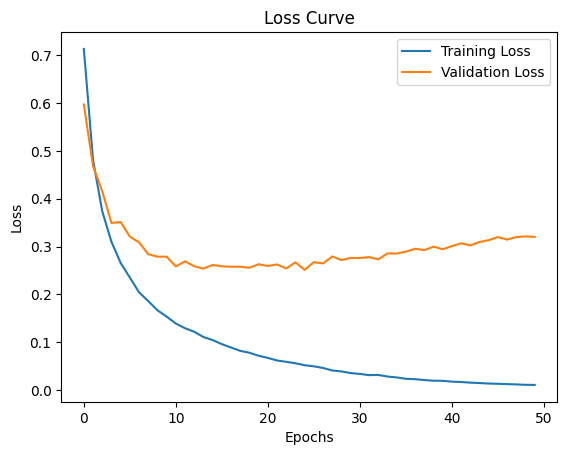

In [ ]:
# Import necessary libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Check TensorFlow version
print("TensorFlow version:", tf.__version__)

### 1. Generate a Synthetic Dataset

# Generate a synthetic dataset
X, y = make_classification(n_samples=1000,
                           n_features=20,
                           n_informative=15,
                           n_redundant=5,
                           n_classes=2,
                           random_state=42)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### 2. Build a Simple Neural Network Model

# Create a Sequential model
model = Sequential([
    Dense(64, activation='relu', input_dim=20),  # Input layer with 64 neurons and ReLU activation
    Dense(32, activation='relu'),                # Hidden layer with 32 neurons and ReLU activation
    Dense(1, activation='sigmoid')               # Output layer with 1 neuron and sigmoid activation for binary classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Print model summary
print("Model Summary:")
model.summary()

### 3. Train the Model

# Train the model on the dataset
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=1)

### 4. Evaluate the Model

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

### 5. Make Predictions

# Make predictions on the test set
predictions = model.predict(X_test)
predicted_classes = (predictions > 0.5).astype(int)

# Print the first few predictions
print("First few predictions:", predicted_classes[:5].flatten())
print("Actual values:", y_test[:5])

### 6. Visualize the Learning Curve

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
